 <a href="https://colab.research.google.com/github/geoUFSC/python/blob/main/TaludeInfinito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



## Talude infinito de referência

<p align="center">
<img src="images/TaludeReferencia.png" alt="" width="500">
</p>

In [29]:
# Pacotes necessários
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [16]:
# ==========================================================
# FUNÇÕES
# ==========================================================

def fs_seco(c, H, gamma, beta_graus, phi_graus):
    """
    Calcula o fator de segurança (FS) de um talude infinito seco.

    Parâmetros:
    c : coesão efetiva do solo (kPa ou kN/m²)
    H : espessura vertical do solo acima da superfície de ruptura (m)
    gamma : peso específico do solo (kN/m³)
    beta_graus : inclinação do talude (graus)
    phi_graus : ângulo de atrito efetivo do solo (graus)

    Retorna:
    FS : fator de segurança
    """
    beta = np.radians(beta_graus)
    phi = np.radians(phi_graus)

    termo_coesao = c / (H * gamma * (np.cos(beta)**2) * np.tan(beta))
    termo_atrito = np.tan(phi) / np.tan(beta)

    fs = termo_coesao + termo_atrito
    return fs


def fs_fluxo_paral(c, gamma_sat, H, Hw, gamma_w, beta_graus, phi_graus):
    """
    Calcula o fator de segurança (FS) de um talude infinito
    com percolação paralela ao talude.

    Parâmetros:
    c : coesão efetiva do solo (kPa ou kN/m²)
    gamma_sat : peso específico saturado do solo (kN/m³)
    H : espessura vertical do solo acima da superfície de ruptura (m)
    Hw : altura da água no solo (m)
    gamma_w : peso específico da água (kN/m³)
    beta_graus : inclinação do talude (graus)
    phi_graus : ângulo de atrito efetivo do solo (graus)

    Retorna:
    FS : fator de segurança
    """
    beta = np.radians(beta_graus)
    phi = np.radians(phi_graus)

    termo_coesao = c / ( H * gamma_sat * (np.cos(beta)**2) * np.tan(beta))
    termo_atrito = ((H * gamma_sat - Hw * gamma_w) / (gamma_sat * H)) * (np.tan(phi) / np.tan(beta))

    fs = termo_coesao + termo_atrito
    return fs


def classificar_fs(fs):
    """
    Classifica a estabilidade do talude a partir do FS.
    """
    if fs < 1.0:
        return "Instável"
    elif fs < 1.2:
        return "Condição de atenção"
    else:
        return "Estável"



In [17]:
# ==========================================================
# TESTES
# ==========================================================

# Cálculo do FS para talude seco
## Parâmetros de exemplo
c = 28.78  # kPa
gamma = 18.0  # kN/m³
H = 3.0  # m
phi = 22.38  # graus
beta = 25 # graus

fs_seco_val = fs_seco(c, H, gamma, beta, phi)
if round(fs_seco_val, 2) == 2.27:
    print("FS para talude seco está correto (2.27).")
    #print(f"Fator de Segurança (FS) para talude seco: {fs_seco_val:.2f} - {classificar_fs(fs_seco_val)}")
else:
    print(f"FS para talude seco está incorreto. Valor calculado: {fs_seco_val:.2f}, valor esperado: 2.27.")

# Cálculo do FS para talude com percolação paralela
## Parâmetros de exemplo
c = 28.78  # kPa
gamma_sat = 20.0  # kN/m³
gamma_w = 10  # kN/m³
H = 3.0  # m
Hw = 3.0  # m (0 = condição seca)
phi = 22.38  # graus
beta = 25 # graus

fs_fluxo_val = fs_fluxo_paral(c, gamma_sat, H, Hw, gamma_w, beta, phi)
if round(fs_fluxo_val, 2) == 1.69:
    print("FS para talude com percolação paralela está correto (1.69).")
    #print(f"Fator de Segurança (FS) para talude com percolação paralela: {fs_fluxo_val:.2f} - {classificar_fs(fs_fluxo_val)}")
else:
    print(f"FS para talude com percolação paralela está incorreto. Valor calculado: {fs_fluxo_val:.2f}, valor esperado: 1.69.")

# As duas funções devem convergir quando Hw = 0 (condição seca) e gamma_sat = gamma. 
## Parâmetros de exemplo
c = 28.78  # kPa
gamma = 18.0  # kN/m³
gamma_sat = 18.0  # kN/m³
gamma_w = 10  # kN/m³
H = 3.0  # m
Hw = 0  # m (0 = condição seca)
phi = 22.38  # graus
beta = 25 # graus

fs_seco_val = fs_seco(c, H, gamma, beta, phi)
fs_fluxo_val = fs_fluxo_paral(c, gamma_sat, H, Hw, gamma_w, beta, phi)
if round(fs_seco_val, 2) == round(fs_fluxo_val, 2):
    print(f"As funções convergem para as mesmas condições (condição seca), {fs_seco_val:.2f} = {fs_fluxo_val:.2f}.")
    #print(f"Fator de Segurança (FS) para talude seco: {fs_seco_val:.2f} - {classificar_fs(fs_seco_val)}")
    #print(f"Fator de Segurança (FS) para talude com percolação paralela: {fs_fluxo_val:.2f} - {classificar_fs(fs_fluxo_val)}")
else:
    print(f"As funções não convergem para as mesmas condições. FS seco: {fs_seco_val:.2f}, FS percolação paralela: {fs_fluxo_val:.2f}.")    


FS para talude seco está correto (2.27).
FS para talude com percolação paralela está correto (1.69).
As funções convergem para as mesmas condições (condição seca), 2.27 = 2.27.


In [18]:
# ==========================================================
# DADOS DO PROBLEMA
# ==========================================================

H = 2.0             # espessura vertical do solo (m)
Hw = 2.0            # altura da água no solo (m)
beta = 28.0         # inclinação do talude (graus)
gamma = 18.0        # peso específico natural do solo (kN/m³)
gamma_sat = 20.0    # peso específico saturado do solo (kN/m³)
gamma_w = 9.81      # peso específico da água (kN/m³)
phi = 30.0          # ângulo de atrito efetivo (graus)

c_com = 12.0        # coesão do caso com coesão
c_sem = 0.0         # coesão do caso sem coesão



In [19]:
# ==========================================================
# CÁLCULOS DOS QUATRO CENÁRIOS
# ==========================================================

fs_seco_com = fs_seco(c_com, H, gamma, beta, phi)
fs_seco_sem = fs_seco(c_sem, H, gamma, beta, phi)

fs_perc_com = fs_fluxo_paral(c_com, gamma_sat, H, Hw, gamma_w, beta, phi)
fs_perc_sem = fs_fluxo_paral(c_sem, gamma_sat, H, Hw, gamma_w, beta, phi)



In [20]:
# ==========================================================
# RESULTADOS NA TELA
# ==========================================================

print("=" * 60)
print("RESULTADOS DO EXERCÍCIO")
print("=" * 60)

print(f"1) Talude seco com coesão:            FS = {fs_seco_com:.2f}  --> {classificar_fs(fs_seco_com)}")
print(f"2) Talude seco sem coesão:            FS = {fs_seco_sem:.2f}  --> {classificar_fs(fs_seco_sem)}")
print(f"3) Percolação paralela com coesão:    FS = {fs_perc_com:.2f}  --> {classificar_fs(fs_perc_com)}")
print(f"4) Percolação paralela sem coesão:    FS = {fs_perc_sem:.2f}  --> {classificar_fs(fs_perc_sem)}")



RESULTADOS DO EXERCÍCIO
1) Talude seco com coesão:            FS = 1.89  --> Estável
2) Talude seco sem coesão:            FS = 1.09  --> Condição de atenção
3) Percolação paralela com coesão:    FS = 1.28  --> Estável
4) Percolação paralela sem coesão:    FS = 0.55  --> Instável


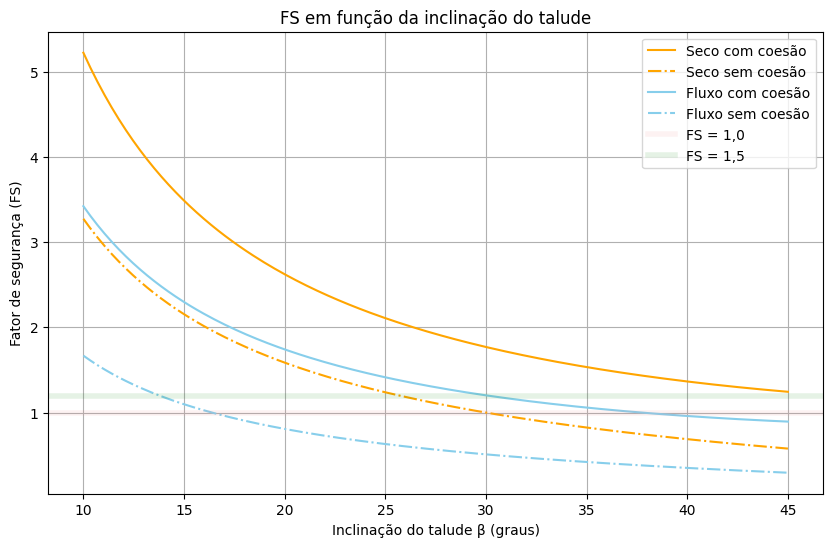

In [21]:
# ==========================================================
# GRÁFICO 1 - FS x INCLINAÇÃO DO TALUDE
# ==========================================================

betas = np.linspace(10, 45, 200)

g1 = fs_seco(c_com, H, gamma, betas, phi)
g2 = fs_seco(c_sem, H, gamma, betas, phi)
g3 = fs_fluxo_paral(c_com, gamma_sat, H, Hw, gamma_w, betas, phi)
g4 = fs_fluxo_paral(c_sem, gamma_sat, H, Hw, gamma_w, betas, phi)

plt.figure(figsize=(10, 6))
plt.plot(betas, g1, label='Seco com coesão', color='orange', linestyle='-')
plt.plot(betas, g2, label='Seco sem coesão', color='orange', linestyle='-.')
plt.plot(betas, g3, label='Fluxo com coesão', color='skyblue', linestyle='-')
plt.plot(betas, g4, label='Fluxo sem coesão', color='skyblue', linestyle='-.')
plt.axhline(1.0, linestyle='-', label='FS = 1,0', color='lightcoral', alpha=0.1, linewidth=4)
plt.axhline(1.2, linestyle='-', label='FS = 1,5', color='green', alpha=0.1, linewidth=4)
#print the background in lightcoral alpha=0.1 from 0-1, orange from 1-1.5, in green alpha=0.1 from 1.2 onwards
#plt.fill_between(betas, 0, 1.0, color='lightcoral', alpha=0.1)
#plt.fill_between(betas, 1.0, 1.2, color='orange', alpha=0.1)
#plt.fill_between(betas, 1.2, max(max(g1), max(g2), max(g3), max(g4)), color='green', alpha=0.1)

plt.xlabel('Inclinação do talude β (graus)')
plt.ylabel('Fator de segurança (FS)')
plt.title('FS em função da inclinação do talude')
plt.grid(True)
plt.legend()
plt.show()



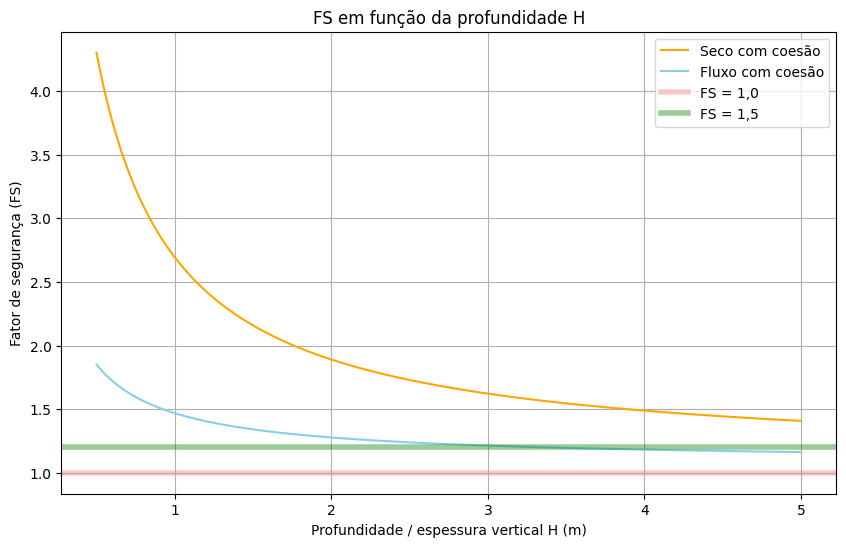

In [22]:
# ==========================================================
# GRÁFICO 2 - FS x PROFUNDIDADE H
# ==========================================================

Hs = np.linspace(0.5, 5.0, 200)

g5 = fs_seco(c_com, Hs, gamma, beta, phi)
g6 = fs_fluxo_paral(c_com, gamma_sat, Hs, Hw, gamma_w, beta, phi)

plt.figure(figsize=(10, 6))
plt.plot(Hs, g5, label='Seco com coesão', color='orange', linestyle='-')
plt.plot(Hs, g6, label='Fluxo com coesão', color='skyblue', linestyle='-')
plt.axhline(1.0, linestyle='-', label='FS = 1,0', color='lightcoral', alpha=0.4, linewidth=4)
plt.axhline(1.2, linestyle='-', label='FS = 1,5', color='green', alpha=0.4, linewidth=4)
plt.xlabel('Profundidade / espessura vertical H (m)')
plt.ylabel('Fator de segurança (FS)')
plt.title('FS em função da profundidade H')
plt.grid(True)
plt.legend()
plt.show()



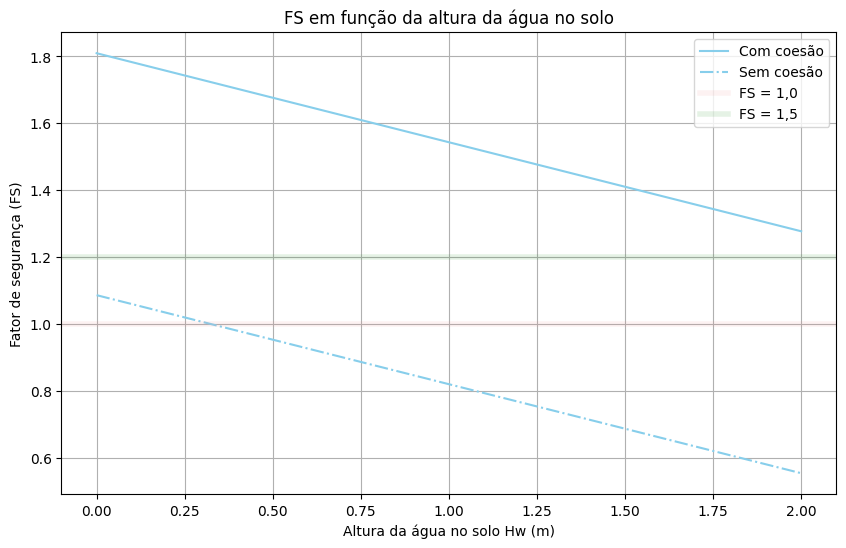

In [23]:
# ==========================================================
# GRÁFICO 3 - FS x ALTURA DA ÁGUA Hw
# ==========================================================

Hws = np.linspace(0.0, H, 200)

g7 = fs_fluxo_paral(c_com, gamma_sat, H, Hws, gamma_w, beta, phi)
g8 = fs_fluxo_paral(c_sem, gamma_sat, H, Hws, gamma_w, beta, phi)

plt.figure(figsize=(10, 6))
plt.plot(Hws, g7, label='Com coesão', color='skyblue', linestyle='-')
plt.plot(Hws, g8, label='Sem coesão', color='skyblue', linestyle='-.')
plt.axhline(1.0, linestyle='-', label='FS = 1,0', color='lightcoral', alpha=0.1, linewidth=4)
plt.axhline(1.2, linestyle='-', label='FS = 1,5', color='green', alpha=0.1, linewidth=4)
plt.xlabel('Altura da água no solo Hw (m)')
plt.ylabel('Fator de segurança (FS)')
plt.title('FS em função da altura da água no solo')
plt.grid(True)
plt.legend()
plt.show()